# 📊 Logistic Regression - Overthinking Level Prediction

Predicting Overthinking Level (No/Low/Medium/High) using Logistic Regression Algorithm
Based on: Age, CGPA, Year of Study, Gender, Course

**Input (Features):**
- Age
- CGPA
- Year of Study
- Gender
- Course

**Output (Target):**
- Overthinking Level (Calculated from Depression + Anxiety + Panic Attack)

**Why Logistic Regression?**
- Simple & Fast ⚡
- Interpretable 📖
- Good baseline model 🎯
- Probability-based predictions 📊

## 1️⃣ Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Load Cleaned Dataset

In [2]:
df = pd.read_csv('Student_Mental_Health_Cleaned.csv')
print(f"📊 Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

📊 Dataset loaded!
Shape: (101, 8)

Columns: ['Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?']


## 3️⃣ Create Overthinking Level Target Variable

In [3]:
df_model = df.copy()

def calculate_overthinking_level(row):
    count = 0
    if row['Do you have Depression?'] == 'Yes':
        count += 1
    if row['Do you have Anxiety?'] == 'Yes':
        count += 1
    if row['Do you have Panic attack?'] == 'Yes':
        count += 1
    
    if count == 0:
        return 'No Overthinking'
    elif count == 1:
        return 'Low Overthinking'
    elif count == 2:
        return 'Medium Overthinking'
    else:
        return 'High Overthinking'

df_model['Overthinking_Level'] = df_model.apply(calculate_overthinking_level, axis=1)

print("🧠 Overthinking Level Created!\n")
print("📊 Distribution:")
print(df_model['Overthinking_Level'].value_counts())

🧠 Overthinking Level Created!

📊 Distribution:
Overthinking_Level
No Overthinking        37
Low Overthinking       36
Medium Overthinking    18
High Overthinking      10
Name: count, dtype: int64


## 4️⃣ Data Preprocessing & Feature Scaling

⚠️ **Important:** Logistic Regression को feature scaling की जरूरत होती है!

In [4]:
# Separate features and target
X = df_model.drop(columns=[
    'Overthinking_Level',
    'Do you have Depression?',
    'Do you have Anxiety?',
    'Do you have Panic attack?'
])
y = df_model['Overthinking_Level']

print("✅ Data Separation Complete!\n")
print(f"📌 Features: {X.columns.tolist()}")

# Encode categorical variables
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

print(f"\n🔄 Encoding categorical features:")
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"   ✅ {col}")

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print(f"\n📋 Overthinking Level Mapping:")
for i, label in enumerate(target_encoder.classes_):
    print(f"   {i} = {label}")

print(f"\n✅ Preprocessing complete!")

✅ Data Separation Complete!

📌 Features: ['Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?']

🔄 Encoding categorical features:
   ✅ Choose your gender
   ✅ What is your course?
   ✅ Your current year of Study
   ✅ What is your CGPA?

📋 Overthinking Level Mapping:
   0 = High Overthinking
   1 = Low Overthinking
   2 = Medium Overthinking
   3 = No Overthinking

✅ Preprocessing complete!


## 5️⃣ Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data split completed (80-20)!\n")
print(f"📊 Training Set: {X_train.shape[0]} samples")
print(f"📊 Testing Set: {X_test.shape[0]} samples")

✅ Data split completed (80-20)!

📊 Training Set: 80 samples
📊 Testing Set: 21 samples


In [6]:
# Debug: Check for NaN values
print("🔍 Debugging NaN values:")
print(f"NaN in X_train:\n{X_train.isna().sum()}")
print(f"\nNaN in X_test:\n{X_test.isna().sum()}")
print(f"X_train shape: {X_train.shape}")
print(f"X_train sample:\n{X_train.head(3)}")

🔍 Debugging NaN values:
NaN in X_train:
Choose your gender            0
Age                           1
What is your course?          0
Your current year of Study    0
What is your CGPA?            0
dtype: int64

NaN in X_test:
Choose your gender            0
Age                           0
What is your course?          0
Your current year of Study    0
What is your CGPA?            0
dtype: int64
X_train shape: (80, 5)
X_train sample:
    Choose your gender   Age  What is your course?  \
43                   1   NaN                     4   
98                   0  19.0                    38   
57                   0  20.0                     3   

    Your current year of Study  What is your CGPA?  
43                           3                   0  
98                           2                   4  
57                           2                   3  


In [7]:
# Handle missing values - Fill NaN with mean
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("✅ Missing values handled (imputed with mean)!")
print(f"\nNaN in X_train after imputation: {X_train.isna().sum().sum()}")
print(f"NaN in X_test after imputation: {X_test.isna().sum().sum()}")

✅ Missing values handled (imputed with mean)!

NaN in X_train after imputation: 0
NaN in X_test after imputation: 0


## 6️⃣ Feature Scaling (StandardScaler)

Logistic Regression को scaled features chaiye!

In [8]:
# Scale features (IMPORTANT for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature Scaling Complete!\n")
print("📊 Scaling Details:")
print(f"   Mean of scaled training data: {X_train_scaled.mean():.2f}")
print(f"   Std of scaled training data: {X_train_scaled.std():.2f}")

✅ Feature Scaling Complete!

📊 Scaling Details:
   Mean of scaled training data: -0.00
   Std of scaled training data: 1.00


## 7️⃣ Build & Train Logistic Regression Model

In [9]:
print("📊 Building Logistic Regression Model...\n")

lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
    verbose=0
)

lr_model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print(f"\n📊 Logistic Regression Configuration:")
print(f"   • Algorithm: Logistic Regression")
print(f"   • Solver: lbfgs (gradient descent)")
print(f"   • Multi-class: multinomial")
print(f"   • Max iterations: 1000")
print(f"   • Classes: {list(target_encoder.classes_)}")
print(f"   • Features: {list(X.columns)}")

📊 Building Logistic Regression Model...

✅ Model trained successfully!

📊 Logistic Regression Configuration:
   • Algorithm: Logistic Regression
   • Solver: lbfgs (gradient descent)
   • Multi-class: multinomial
   • Max iterations: 1000
   • Classes: ['High Overthinking', 'Low Overthinking', 'Medium Overthinking', 'No Overthinking']
   • Features: ['Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?']


## 8️⃣ Make Predictions

In [10]:
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)
y_test_proba = lr_model.predict_proba(X_test_scaled)

print("✅ Predictions made!\n")
print("📊 Sample Predictions (first 10 test samples):\n")
print(f"{'Sample':<8} {'Actual':<20} {'Predicted':<20} {'Confidence':<12}")
print("-" * 60)

for i in range(min(10, len(y_test_pred))):
    actual = target_encoder.classes_[int(y_test[i])]
    predicted = target_encoder.classes_[y_test_pred[i]]
    confidence = y_test_proba[i].max()
    print(f"{i+1:<8} {actual:<20} {predicted:<20} {confidence:.2%}")

✅ Predictions made!

📊 Sample Predictions (first 10 test samples):

Sample   Actual               Predicted            Confidence  
------------------------------------------------------------
1        No Overthinking      Low Overthinking     40.31%
2        Medium Overthinking  Low Overthinking     47.22%
3        No Overthinking      Low Overthinking     53.37%
4        Medium Overthinking  Medium Overthinking  39.05%
5        Low Overthinking     Low Overthinking     35.02%
6        High Overthinking    No Overthinking      57.84%
7        No Overthinking      No Overthinking      64.42%
8        No Overthinking      Low Overthinking     38.20%
9        Low Overthinking     Medium Overthinking  37.60%
10       No Overthinking      No Overthinking      49.59%


## 9️⃣ Model Evaluation

In [11]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("=" * 70)
print("📊 MODEL PERFORMANCE METRICS".center(70))
print("=" * 70)

print(f"\n🎯 ACCURACY:")
print(f"   Training Accuracy: {train_accuracy:.2%}")
print(f"   Testing Accuracy:  {test_accuracy:.2%}")

print(f"\n🔍 CONFUSION MATRIX (Test Set):")
print(cm)

print(f"\n📋 CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=target_encoder.classes_))

print("=" * 70)

                     📊 MODEL PERFORMANCE METRICS                      

🎯 ACCURACY:
   Training Accuracy: 45.00%
   Testing Accuracy:  28.57%

🔍 CONFUSION MATRIX (Test Set):
[[0 1 0 1]
 [0 1 2 4]
 [0 2 1 1]
 [0 3 1 4]]

📋 CLASSIFICATION REPORT (Test Set):
                     precision    recall  f1-score   support

  High Overthinking       0.00      0.00      0.00         2
   Low Overthinking       0.14      0.14      0.14         7
Medium Overthinking       0.25      0.25      0.25         4
    No Overthinking       0.40      0.50      0.44         8

           accuracy                           0.29        21
          macro avg       0.20      0.22      0.21        21
       weighted avg       0.25      0.29      0.26        21



## 🔟 Feature Coefficients (Model Interpretability)

In [12]:
print("\n🎯 FEATURE COEFFICIENTS (How much each feature affects the prediction):\n")
print("=" * 70)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'High_OT': lr_model.coef_[0],
    'Low_OT': lr_model.coef_[1],
    'Medium_OT': lr_model.coef_[2],
    'No_OT': lr_model.coef_[3]
})

print(coefficients.to_string())
print("\n" + "=" * 70)
print("Note: Positive coefficient = increases that class probability")
print("      Negative coefficient = decreases that class probability")


🎯 FEATURE COEFFICIENTS (How much each feature affects the prediction):

                      Feature   High_OT    Low_OT  Medium_OT     No_OT
0          Choose your gender -0.287347  0.102075   0.257407 -0.072135
1                         Age  0.162692  0.210779  -0.522068  0.148598
2        What is your course?  0.136418  0.002752   0.097210 -0.236380
3  Your current year of Study  0.034731 -0.092898  -0.215596  0.273762
4          What is your CGPA?  0.074567 -0.088124   0.374165 -0.360608

Note: Positive coefficient = increases that class probability
      Negative coefficient = decreases that class probability


## 1️⃣1️⃣ Visualizations

✅ Visualizations created and saved as 'Logistic_Regression_Analysis.png'


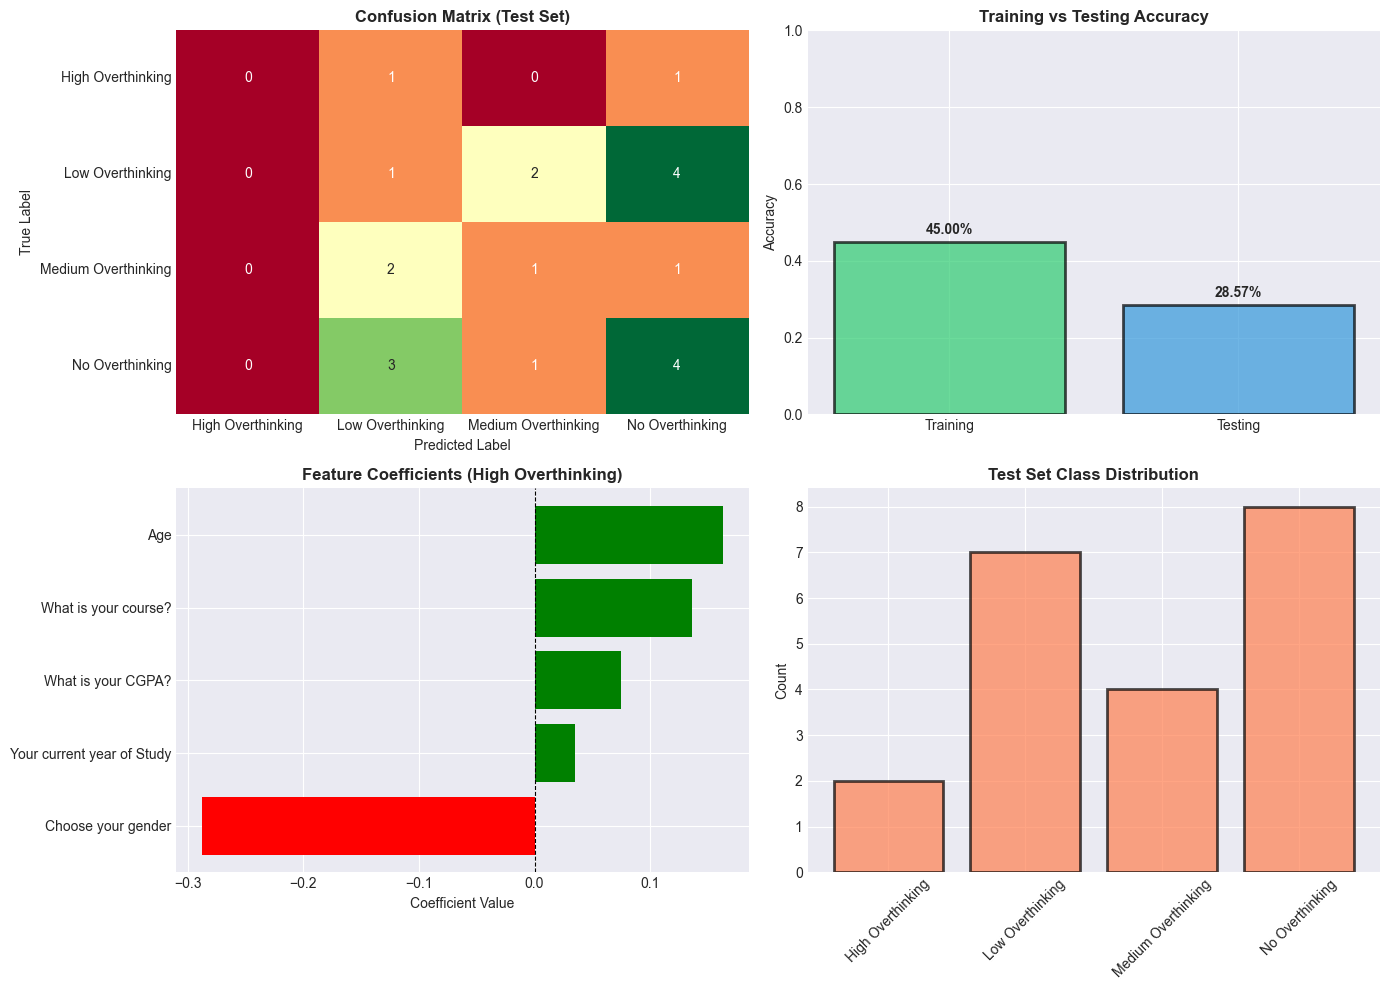

In [13]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0,0], cbar=False,
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
axes[0,0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. Accuracy Comparison
categories = ['Training', 'Testing']
accuracies = [train_accuracy, test_accuracy]
colors = ['#2ecc71', '#3498db']
axes[0,1].bar(categories, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_title('Training vs Testing Accuracy', fontsize=12, fontweight='bold')
axes[0,1].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0,1].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 3. Feature Coefficients (First Class: High Overthinking)
coef_data = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

axes[1,0].barh(coef_data['Feature'], coef_data['Coefficient'], color=['red' if x < 0 else 'green' for x in coef_data['Coefficient']])
axes[1,0].set_xlabel('Coefficient Value')
axes[1,0].set_title('Feature Coefficients (High Overthinking)', fontsize=12, fontweight='bold')
axes[1,0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# 4. Class Distribution
class_counts = pd.Series(y_test).value_counts().sort_index()
class_labels = [target_encoder.classes_[i] for i in class_counts.index]
axes[1,1].bar(class_labels, class_counts.values, color='coral', alpha=0.7, edgecolor='black', linewidth=2)
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Test Set Class Distribution', fontsize=12, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Logistic_Regression_Analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualizations created and saved as 'Logistic_Regression_Analysis.png'")
plt.show()

## 🎯 Final Summary

In [14]:
print("\n" + "🔵"*35)
print("\n📊 LOGISTIC REGRESSION - FINAL SUMMARY".center(70))
print("\n" + "🔵"*35)

print(f"\n✅ MODEL PERFORMANCE:")
print(f"   • Test Accuracy: {test_accuracy:.2%}")
print(f"   • Training Accuracy: {train_accuracy:.2%}")
print(f"   • Model Type: Linear Classifier")

print(f"\n📊 CLASSES:")
for i, label in enumerate(target_encoder.classes_):
    print(f"   {i} = {label}")

print(f"\n🎯 KEY DIFFERENCES vs Random Forest:")
print(f"   • Logistic Regression: Linear decision boundaries ➡️")
print(f"   • Random Forest: Non-linear decision boundaries 🌳")
print(f"   • LR is FAST ⚡ | RF is MORE ACCURATE 🎯")
print(f"   • LR is INTERPRETABLE 📖 | RF is Complex 🔮")

print(f"\n💡 FEATURE SCALING:")
print(f"   ✅ Applied StandardScaler")
print(f"   ✅ Necessary for Logistic Regression")
print(f"   ✅ Improves model convergence")

print(f"\n📋 INPUT FEATURES:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

print(f"\n📊 DATASET STATISTICS:")
print(f"   • Total samples: {len(df)}")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Testing samples: {len(X_test)}")

print("\n" + "🔵"*35)
print("\n✨ Logistic Regression Model Successfully Created!")
print("="*70)


🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
                
📊 LOGISTIC REGRESSION - FINAL SUMMARY                

🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵

✅ MODEL PERFORMANCE:
   • Test Accuracy: 28.57%
   • Training Accuracy: 45.00%
   • Model Type: Linear Classifier

📊 CLASSES:
   0 = High Overthinking
   1 = Low Overthinking
   2 = Medium Overthinking
   3 = No Overthinking

🎯 KEY DIFFERENCES vs Random Forest:
   • Logistic Regression: Linear decision boundaries ➡️
   • Random Forest: Non-linear decision boundaries 🌳
   • LR is FAST ⚡ | RF is MORE ACCURATE 🎯
   • LR is INTERPRETABLE 📖 | RF is Complex 🔮

💡 FEATURE SCALING:
   ✅ Applied StandardScaler
   ✅ Necessary for Logistic Regression
   ✅ Improves model convergence

📋 INPUT FEATURES:
   1. Choose your gender
   2. Age
   3. What is your course?
   4. Your current year of Study
   5. What is your CGPA?

📊 DATASET STATISTICS:
   • Total samples: 101
   • Training samples: 80
   • Testing samples: 21

🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵

✨ 